# 👁️ Vision-Language Fine-tuning Guide
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/togethercomputer/together-cookbook/blob/main/Finetuning/Vision_Language_Finetuning.ipynb)

Vision-Language Models (VLMs) combine the power of language understanding with visual comprehension, enabling models to process and reason about images alongside text. Fine-tuning VLMs allows you to adapt these models for specialized visual tasks like document understanding, receipt parsing, medical image analysis, and more.

This notebook provides a step-by-step guide to fine-tuning Vision-Language Models using the Together AI platform. We'll train a model to extract structured JSON data from receipt images using the [CORD-v2 dataset](https://huggingface.co/datasets/naver-clova-ix/cord-v2).

We will cover:

1. **Dataset Exploration:** Loading and understanding the CORD-v2 receipt dataset.
2. **Data Transformation:** Converting images and annotations to the VLM fine-tuning format with base64-encoded images.
3. **Data Upload:** Uploading the prepared dataset to Together AI.
4. **Fine-tuning Job Launch:** Configuring and initiating a VLM fine-tuning job.
5. **Job Monitoring:** Checking the status and progress of your fine-tuning job.
6. **Inference:** Using your fine-tuned VLM for receipt parsing.

By following this guide, you'll learn how to create specialized VLMs for document understanding tasks using Together AI.

## Setup and Installation
---
First, install the necessary Python libraries:
- `together`: The official Together AI Python client for interacting with the API.
- `datasets`: A library from Hugging Face for easily downloading and manipulating datasets.
- `Pillow`: For image processing and manipulation.
- `tqdm`: For progress bars.

In [4]:
!pip install -qU together datasets Pillow tqdm

Using Python 3.12.8 environment at: /opt/anaconda3/envs/cookbook
Audited 4 packages in 9ms


In [5]:
import os
import json
import base64
import io
from together import Together
from datasets import load_dataset
from PIL import Image
from tqdm.auto import tqdm

# Setup Together AI client
TOGETHER_API_KEY = os.getenv("TOGETHER_API_KEY")
WANDB_API_KEY = os.getenv("WANDB_API_KEY")  # Optional: for logging to WandB

client = Together(api_key=TOGETHER_API_KEY)

## 1. Dataset Exploration
---
We'll use the **CORD-v2** (Consolidated Receipt Dataset) from NAVER CLOVA. This dataset contains:
- **800 training images** of receipts
- **100 validation images**
- **100 test images**

Each image comes with structured JSON annotations containing menu items, prices, quantities, subtotals, and totals extracted from the receipt.

In [6]:
# Load the CORD-v2 dataset
dataset = load_dataset("naver-clova-ix/cord-v2")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 800
    })
    validation: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 100
    })
    test: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 100
    })
})


In [7]:
# Let's examine a sample from the training set
sample = dataset["train"][15]
print("Keys in each sample:", sample.keys())

Keys in each sample: dict_keys(['image', 'ground_truth'])


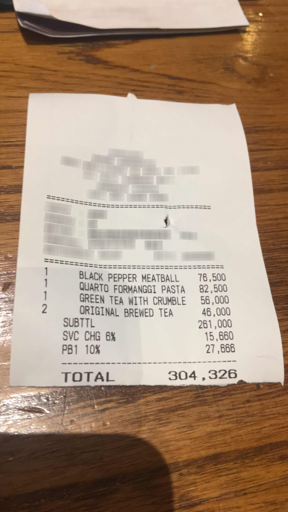

In [9]:
# Display a sample receipt image
img = sample["image"]
img.resize((img.width // 8, img.height // 8))

In [10]:
# Parse and display the ground truth JSON
ground_truth = json.loads(sample["ground_truth"])
print("Ground truth structure:")
print(json.dumps(ground_truth["gt_parse"], indent=2))

Ground truth structure:
{
  "menu": [
    {
      "nm": "BLACK PEPPER MEATBALL",
      "cnt": "1",
      "price": "76,500"
    },
    {
      "nm": "QUARTO FORMANGGI PASTA",
      "cnt": "1",
      "price": "82,500"
    },
    {
      "nm": "GREEN TEA WITH CRUMBLE",
      "cnt": "1",
      "price": "56,000"
    },
    {
      "nm": "ORIGINAL BREWED TEA",
      "cnt": "2",
      "price": "46,000"
    }
  ],
  "sub_total": {
    "subtotal_price": "261,000",
    "service_price": "15,660",
    "tax_price": "27,666"
  },
  "total": {
    "total_price": "304,326"
  }
}


The `gt_parse` field contains the structured data we want the model to extract:
- **menu**: List of items with name (`nm`), count (`cnt`), and price (`price`)
- **sub_total**: Subtotal, service charges, tax, etc.
- **total**: Final total price

Our goal is to fine-tune a VLM to take a receipt image as input and output this structured JSON.

## 2. Data Transformation to VLM Format
---
VLM fine-tuning on Together AI requires a specific format where images are base64-encoded and included in the message content.

### VLM Data Format
```json
{
  "messages": [
    {
      "role": "system",
      "content": [{"type": "text", "text": "Your system prompt here"}]
    },
    {
      "role": "user",
      "content": [
        {"type": "text", "text": "Your prompt here"},
        {"type": "image_url", "image_url": {"url": "data:image/jpeg;base64,/9j/4AAQ..."}}
      ]
    },
    {
      "role": "assistant",
      "content": [{"type": "text", "text": "Model response"}]
    }
  ]
}
```

### Key Requirements:
- Images must be **base64-encoded** with proper MIME type prefix
- Maximum **10 images per example**
- Maximum **10MB per image**
- Supported formats: PNG, JPEG, WEBP

In [65]:
from pydantic import Field, BaseModel
from typing import Optional

class MenuItem(BaseModel):
    nm: str = Field(..., description="Name of the menu item")
    cnt: str = Field(..., description="Count of the menu item, as a string")
    price: str = Field(..., description="Price of the menu item, as a string")

class SubTotal(BaseModel):
    subtotal_price: str = Field(..., description="Subtotal price for all menu items, as a string")
    service_price: Optional[str] = Field(None, description="Service charge, if listed, as a string")
    tax_price: Optional[str] = Field(None, description="Tax amount, if listed, as a string")

class Total(BaseModel):
    total_price: str = Field(..., description="Total price, as a string")

class ReceiptParse(BaseModel):
    menu: list[MenuItem] = Field(..., description="List of items purchased, each including name (nm), count (cnt), and price")
    sub_total: SubTotal = Field(..., description="Subtotal information including subtotal price and optionally tax and service fee")
    total: Total = Field(..., description="Total amount to be paid, as a string")


In [17]:
# System prompt for the receipt parsing task
SYSTEM_PROMPT = (
    "You are a receipt parsing assistant. When given an image of a receipt, extract all the information and return it as structured JSON.\n\n"
    "The output should follow this format:\n"
    '- "menu": List of items, each with "nm" (name), "cnt" (count), and "price"\n'
    '- "sub_total": Object with subtotal_price, tax_price, service_price if applicable\n'
    '- "total": Object with total_price\n\n'
    f"Return only valid JSON and follow this schema {json.dumps(ReceiptParse.model_json_schema())}."
)

USER_PROMPT = "Extract all items, prices, and totals from this receipt image. Return the data as structured JSON."

In [19]:
def image_to_base64(image: Image.Image, max_size: int = 1024) -> str:
    """
    Convert a PIL Image to a base64-encoded string.
    Optionally resize if the image is too large.
    
    Args:
        image: PIL Image object
        max_size: Maximum dimension (width or height) for resizing
    
    Returns:
        Base64-encoded string with data URI prefix
    """
    # Resize if needed to stay under size limits
    if max(image.size) > max_size:
        ratio = max_size / max(image.size)
        new_size = (int(image.size[0] * ratio), int(image.size[1] * ratio))
        image = image.resize(new_size, Image.Resampling.LANCZOS)
    
    # Convert to RGB if necessary (handles RGBA, P mode, etc.)
    if image.mode not in ('RGB', 'L'):
        image = image.convert('RGB')
    
    # Save to bytes buffer
    buffer = io.BytesIO()
    image.save(buffer, format='JPEG', quality=85)
    buffer.seek(0)
    
    # Encode to base64
    base64_string = base64.b64encode(buffer.getvalue()).decode('utf-8')
    
    return f"data:image/jpeg;base64,{base64_string}"

In [22]:
def convert_to_vlm_format(example: dict) -> dict:
    """
    Convert a CORD-v2 dataset example to VLM fine-tuning format.
    
    Args:
        example: A single example from the CORD-v2 dataset
    
    Returns:
        Dictionary in VLM fine-tuning format with messages
    """
    # Get the image and convert to base64
    image = example["image"]
    image_base64 = image_to_base64(image)
    
    # Create the VLM format message
    return {
        "messages": [
            {
                "role": "system",
                "content": [{"type": "text", "text": SYSTEM_PROMPT}]
            },
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": USER_PROMPT},
                    {"type": "image_url", "image_url": {"url": image_base64}}
                ]
            },
            {
                "role": "assistant",
                "content": [{"type": "text", "text": example["ground_truth"]}]
            }
        ]
    }

In [23]:
# Test the conversion on a single example
sample_converted = convert_to_vlm_format(dataset["train"][0])
print("Converted format structure:")
print(f"Number of messages: {len(sample_converted['messages'])}")
print(f"Roles: {[m['role'] for m in sample_converted['messages']]}")
print(f"\nUser content types: {[c['type'] for c in sample_converted['messages'][1]['content']]}")
print(f"\nAssistant response preview:")
print(sample_converted['messages'][2]['content'][0]['text'][:500] + "...")

Converted format structure:
Number of messages: 3
Roles: ['system', 'user', 'assistant']

User content types: ['text', 'image_url']

Assistant response preview:
{"gt_parse": {"menu": [{"nm": "Nasi Campur Bali", "cnt": "1 x", "price": "75,000"}, {"nm": "Bbk Bengil Nasi", "cnt": "1 x", "price": "125,000"}, {"nm": "MilkShake Starwb", "cnt": "1 x", "price": "37,000"}, {"nm": "Ice Lemon Tea", "cnt": "1 x", "price": "24,000"}, {"nm": "Nasi Ayam Dewata", "cnt": "1 x", "price": "70,000"}, {"nm": "Free Ice Tea", "cnt": "3 x", "price": "0"}, {"nm": "Organic Green Sa", "cnt": "1 x", "price": "65,000"}, {"nm": "Ice Tea", "cnt": "1 x", "price": "18,000"}, {"nm": "Ic...


In [24]:
# Convert the training and validation datasets
print("Converting training dataset...")
train_data = []
for example in tqdm(dataset["train"]):
    try:
        converted = convert_to_vlm_format(example)
        train_data.append(converted)
    except Exception as e:
        print(f"Error converting example: {e}")
        continue

print(f"\nConverted {len(train_data)} training examples")

Converting training dataset...


  0%|          | 0/800 [00:00<?, ?it/s]


Converted 800 training examples


In [25]:
print("Converting validation dataset...")
val_data = []
for example in tqdm(dataset["validation"]):
    try:
        converted = convert_to_vlm_format(example)
        val_data.append(converted)
    except Exception as e:
        print(f"Error converting example: {e}")
        continue

print(f"\nConverted {len(val_data)} validation examples")

Converting validation dataset...


  0%|          | 0/100 [00:00<?, ?it/s]


Converted 100 validation examples


In [26]:
# Save to JSONL files
def save_jsonl(data: list, filepath: str):
    """Save a list of dictionaries to a JSONL file."""
    with open(filepath, 'w') as f:
        for item in data:
            f.write(json.dumps(item) + '\n')
    print(f"Saved {len(data)} examples to {filepath}")

save_jsonl(train_data, "cord_vlm_train.jsonl")
save_jsonl(val_data, "cord_vlm_val.jsonl")

Saved 800 examples to cord_vlm_train.jsonl
Saved 100 examples to cord_vlm_val.jsonl


## 3. Upload Data to Together AI
---
Now we'll validate and upload our prepared datasets to Together AI. The `check=True` parameter validates the file format before uploading.

In [27]:
# Check the training file format
from together.utils import check_file

print("Validating training file...")
train_report = check_file("cord_vlm_train.jsonl")
print(json.dumps(train_report, indent=2))

assert train_report["is_check_passed"] == True, "Training file validation failed!"

Validating training file...


Validating file: 800 lines [00:00, 6721.96 lines/s]

{
  "is_check_passed": true,
  "message": "Checks passed",
  "found": true,
  "file_size": 91757103,
  "utf8": true,
  "line_type": true,
  "text_field": true,
  "key_value": true,
  "has_min_samples": true,
  "num_samples": 800,
  "load_json": true,
  "load_csv": null,
  "filetype": "jsonl"
}


In [28]:
# Upload training file
print("Uploading training file...")
train_file = client.files.upload("cord_vlm_train.jsonl", check=True)
print(f"Training file ID: {train_file.id}")

Uploading training file...


Validating file: 800 lines [00:00, 7722.33 lines/s]
Uploading file cord_vlm_train.jsonl: 100%|██████████| 91.8M/91.8M [00:10<00:00, 9.14MB/s]


Training file ID: file-ce443e99-d4b1-4584-bbf0-2f147e9615a1


In [29]:
# Upload validation file
print("Uploading validation file...")
val_file = client.files.upload("cord_vlm_val.jsonl", check=True)
print(f"Validation file ID: {val_file.id}")

Uploading validation file...


Validating file: 100 lines [00:00, 5118.81 lines/s]
Uploading file cord_vlm_val.jsonl: 30.7MB [00:02, 10.3MB/s]                            


Validation file ID: file-7587a733-e672-42e3-8737-aeba1b025f2b


## 4. Launch VLM Fine-tuning Job
---
Now we'll launch the fine-tuning job for our Vision-Language Model.

### VLM-Specific Parameters

| Parameter | Description |
|-----------|-------------|
| `model` | The base VLM to fine-tune (e.g., `Qwen/Qwen3-VL-8B-Instruct`) |
| `lora` | Set to `True` for LoRA fine-tuning (recommended) |
| `train_vision` | Whether to update the vision encoder weights. Set to `False` to freeze the vision encoder (faster, uses less memory) |

🔗 See the [VLM Fine-tuning documentation](https://docs.together.ai/docs/vlm-fine-tuning) for the full list of supported models.

In [ ]:
# Launch the VLM fine-tuning job
# This job should take approximately 20-30 minutes to complete

ft_response = client.fine_tuning.create(
    training_file=train_file.id,
    validation_file=val_file.id,
    model="Qwen/Qwen3-VL-8B-Instruct",
    lora=True,
    train_vision=True,
    n_epochs=10,
    lora_r=64,
    n_checkpoints=1,
    learning_rate=1e-5,
    suffix="cord-receipt-parser",
    wandb_api_key=WANDB_API_KEY,
)

print(f"Fine-tuning job created!")
print(f"Job ID: {ft_response.id}")

Fine-tuning job created!
Job ID: ft-da0de86a-2034


## 5. Monitor Fine-tuning Job
---
You can monitor your fine-tuning job's progress using the Together AI API or the dashboard.

Available methods:
- `client.fine_tuning.list()` - List all jobs
- `client.fine_tuning.retrieve(id=job_id)` - Get job status
- `client.fine_tuning.list_events(id=job_id)` - Get job logs
- `client.fine_tuning.cancel(id=job_id)` - Cancel a job

In [21]:
# Check the status of the fine-tuning job
status = client.fine_tuning.retrieve(ft_response.id)
print(f"Job Status: {status.status}")

Job Status: FinetuneJobStatus.STATUS_QUEUED


In [22]:
# View training logs/events
events = client.fine_tuning.list_events(id=ft_response.id)
for event in events.data:
    print(event.message)

Fine-tuning request created


In [23]:
# Wait for job completion (optional - you can also check the dashboard)
import time

while True:
    status = client.fine_tuning.retrieve(ft_response.id)
    print(f"Status: {status.status}")
    
    if status.status in ["completed", "failed", "cancelled"]:
        break
    
    time.sleep(60)  # Check every minute

print(f"\nFinal status: {status.status}")
if status.status == "completed":
    print(f"Fine-tuned model: {status.output_name}")

Status: FinetuneJobStatus.STATUS_RUNNING
Status: FinetuneJobStatus.STATUS_RUNNING
Status: FinetuneJobStatus.STATUS_RUNNING
Status: FinetuneJobStatus.STATUS_UPLOADING
Status: FinetuneJobStatus.STATUS_COMPRESSING
Status: FinetuneJobStatus.STATUS_COMPLETED

Final status: FinetuneJobStatus.STATUS_COMPLETED
Fine-tuned model: zainhas/Qwen3-VL-8B-Instruct-cord-receipt-parser-dfc22dba


🔗 You can also monitor your job on the [Together AI Fine-tuning Dashboard](https://api.together.ai/fine-tuning) and view WandB logs if you provided an API key.

## 6. Inference with Fine-tuned VLM - Using Dedicated Endpoints
---
Once training is complete, we can use our fine-tuned model for receipt parsing. In order to use the fine-tuned model you can bring up a dedicated endpoints and send requests to it like any other model endpoint.

In [ ]:
# Get the fine-tuned model name
finetuned_model = ft_response.output_name
print(f"Fine-tuned model: {finetuned_model}")

Fine-tuned model: zainhas/Qwen3-VL-8B-Instruct-cord-receipt-parser-dfc22dba-2152afc5


In [52]:
def parse_receipt_json_mode(image: Image.Image, model_name: str) -> dict:
    """
    Parse a receipt image using JSON mode.

    Args:
        image: PIL Image of the receipt
        model_name: Together AI model identifier to use for inference

    Returns:
        Dictionary of parsed receipt data
    """
    image_base64 = image_to_base64(image)

    response = client.chat.completions.create(
        model=model_name,
        messages=[
            {
                "role": "system",
                "content": [{"type": "text", "text": SYSTEM_PROMPT}]
            },
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": USER_PROMPT},
                    {"type": "image_url", "image_url": {"url": image_base64}}
                ]
            },
        ],
        response_format={
            "type": "json_schema",
            "schema": ReceiptParse.model_json_schema(),
        },
        max_tokens=4000,
    )

    return json.loads(response.choices[0].message.content)

In [67]:
# Test on a sample from the test set
test_sample = dataset["test"][2]
test_image = test_sample["image"]

# Display the test image
img = test_image
img.resize((img.width // 4, img.height // 4))

Below we compare the fine-tuned model against the base model on the test sample above.

In [ ]:
# Compare fine-tuned model against the base model
test_sample = dataset["test"][2]
test_image = test_sample["image"]

models_to_test = {
    "Base model": "Qwen/Qwen3-VL-8B-Instruct",
    "Fine-tuned model": finetuned_model,
}

ground_truth = json.loads(test_sample["ground_truth"])
print("Ground Truth:")
print("=" * 50)
print(json.dumps(ground_truth["gt_parse"], indent=2))
print("\n")

for label, model_id in models_to_test.items():
    print(f"{label} output:")
    print("=" * 50)
    output = parse_receipt_json_mode(test_image, model_id)
    print(json.dumps(output, indent=2))
    print("\n")

## Summary
---
In this notebook, we demonstrated how to:

1. **Prepare VLM training data** by converting images to base64 and structuring conversations
2. **Upload data** to Together AI for fine-tuning
3. **Launch a VLM fine-tuning job** using LoRA on Qwen3-VL-8B-Instruct
4. **Monitor training progress** via the API and dashboard
5. **Run inference** with the fine-tuned model using dedicated endpoints

### Key Takeaways
- VLM fine-tuning requires images to be base64-encoded in the message content
- Setting `train_vision=True` fine-tunes the vision encoder alongside the language model for better visual understanding
- Setting `train_vision=False` freezes the vision encoder for faster, cheaper training
- Using Pydantic schemas ensures consistent, validated outputs for downstream processing

### Next Steps
- Try different hyperparameters (learning rate, epochs, LoRA rank)
- Compare results with `train_vision=False` for faster training on tasks that don't require specialized visual understanding
- Apply this approach to other document understanding tasks

🔗 For more details, see the [VLM Fine-tuning documentation](https://docs.together.ai/docs/vlm-fine-tuning).